# 01 - Exploratory Data Analysis
## Multilingual Health QA - MLT1 Final Project

**Goal:** Understand the dataset structure, language distribution, text lengths, and data quality before designing the fine-tuning pipeline.

**Key questions:**
- How many languages/subsets are there, and how balanced are they?
- How long are questions vs answers (for setting max_length)?
- Are there data quality issues (missing values, duplicates)?

In [ ]:
import pandas as pd

DATA_DIR = '/kaggle/input/datasets/jokjohnkur/multilingual-health-qa'

train = pd.read_csv(f'{DATA_DIR}/Train.csv')
test  = pd.read_csv(f'{DATA_DIR}/Test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/SampleSubmission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sample sub shape:", sample_sub.shape)
print()
print("Train columns:", train.columns.tolist())
print()
train.head()

In [ ]:
print("=== Missing Values (Train) ===")
print(train.isnull().sum())
print()
print("=== Missing Values (Test) ===")
print(test.isnull().sum())
print()
print(f"Duplicate input questions  : {train['input'].duplicated().sum()}")
print(f"Duplicate output answers   : {train['output'].duplicated().sum()}")

## Language Distribution

The dataset contains 8 language subsets — 4 African languages and 4 English variants (by country). Let's visualize how samples are distributed across train and test sets.

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12,
})

lang_labels = {
    'Aka_Gha': 'Akan (Ghana)',
    'Amh_Eth': 'Amharic (Ethiopia)',
    'Eng_Eth': 'English (Ethiopia)',
    'Eng_Gha': 'English (Ghana)',
    'Eng_Ken': 'English (Kenya)',
    'Eng_Uga': 'English (Uganda)',
    'Lug_Uga': 'Luganda (Uganda)',
    'Swa_Ken': 'Kiswahili (Kenya)',
}
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#FF5722','#8BC34A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Language Distribution', fontsize=15, fontweight='bold')

train_counts = train['subset'].value_counts()
axes[0].bar([lang_labels[k] for k in train_counts.index], train_counts.values, color=colors)
axes[0].set_title('Training Set', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=35, labelsize=9)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=8, fontweight='bold')

test_counts = test['subset'].value_counts()
axes[1].bar([lang_labels[k] for k in test_counts.index], test_counts.values, color=colors)
axes[1].set_title('Test Set', fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=35, labelsize=9)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTrain distribution:")
print(train_counts)
print("\nTest distribution:")
print(test_counts)

## Text Length Analysis

Questions and answers vary significantly in length across languages. This informs `max_input_length` and `max_target_length` for tokenization during fine-tuning.

In [ ]:
train['input_word_len']  = train['input'].str.split().str.len()
train['output_word_len'] = train['output'].str.split().str.len()

print("=== Input (Question) Word Count ===")
print(train['input_word_len'].describe().round(1))
print()
print("=== Output (Answer) Word Count ===")
print(train['output_word_len'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Text Length Distributions', fontsize=14, fontweight='bold')

axes[0].hist(train['input_word_len'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(train['input_word_len'].mean(), color='red', linestyle='--', label=f"Mean: {train['input_word_len'].mean():.1f}")
axes[0].set_title('Question Word Count')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(train['output_word_len'], bins=50, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].axvline(train['output_word_len'].mean(), color='red', linestyle='--', label=f"Mean: {train['output_word_len'].mean():.1f}")
axes[1].set_title('Answer Word Count')
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

#### ****Check for empty/very short inputs****

In [ ]:
# Check empty or very short inputs
empty_inputs = train[train['input_word_len'] == 0]
print(f"Rows with 0-word input: {len(empty_inputs)}")
print(empty_inputs[['ID', 'input', 'output', 'subset']])

print()
short_inputs = train[train['input_word_len'] <= 2].sort_values('input_word_len')
print(f"\nRows with <=2 word input: {len(short_inputs)}")
print(short_inputs[['ID','input','input_word_len','subset']].head(10))

**Data Quality Note:** Found 1 row (`ID_TR_Eng_Uga_E9A002A4`) with a completely empty `input` field but a valid `output`. This row will be dropped during preprocessing as it provides no learnable signal for the QA task. Short single-word questions like "Syphilis?" or "AIDS?" are legitimate and retained.

#### **Per-language length breakdown**

In [ ]:
lang_stats = train.groupby('subset')[['input_word_len','output_word_len']].mean().round(1)
lang_stats.columns = ['Avg_Q_Words', 'Avg_A_Words']
lang_stats['Max_A_Words'] = train.groupby('subset')['output_word_len'].max()
lang_stats.index = [lang_labels[i] for i in lang_stats.index]
lang_stats = lang_stats.sort_values('Avg_A_Words', ascending=False)
print(lang_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Average Length per Language', fontsize=14, fontweight='bold')

axes[0].barh(lang_stats.index, lang_stats['Avg_Q_Words'], color='#2196F3', alpha=0.85)
axes[0].set_title('Avg Question Length (words)')
for i, v in enumerate(lang_stats['Avg_Q_Words']):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)

axes[1].barh(lang_stats.index, lang_stats['Avg_A_Words'], color='#4CAF50', alpha=0.85)
axes[1].set_title('Avg Answer Length (words)')
for i, v in enumerate(lang_stats['Avg_A_Words']):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### **Sample Q&A pairs per language**

In [ ]:
print("=" * 70)
for lang in sorted(train['subset'].unique()):
    label = lang_labels[lang]
    row = train[train['subset'] == lang].iloc[0]
    print(f"\n {label} — subset: {lang}")
    print(f"Q: {row['input'][:150]}")
    print(f"A: {row['output'][:150]}")
    print("-" * 70)

## EDA Summary & Preprocessing Decisions

### Key Findings
| Insight | Implication |
|---|---|
| 8 subsets: 4 African languages (Akan, Amharic, Luganda, Kiswahili) + 4 English variants | Need a multilingual model (mT5) that handles all scripts |
| Imbalanced: Eng_Uga has 7,624 samples vs Amh_Eth's 1,845 | Monitor per-language scores separately; Amharic likely underperforms |
| Questions avg ~15 words (max 83); Answers avg ~76 words (max 482) | Set `max_input_length=128`, `max_target_length=256` as starting point |
| Akan has longest Q&A (avg Q=29 words, A=106 words) | May need higher `max_target_length` (384–512) for Akan-heavy batches |
| 1 row has empty input with valid output | Drop this row during preprocessing |
| ~39% of answers are duplicated across rows | Reflects standardised health guidance — model can learn common answer patterns |
| No missing values | No imputation needed |

### Preprocessing Plan for `02_baseline.ipynb` and beyond
1. Drop the 1 row with empty `input`
2. Strip leading/trailing whitespace from all text fields
3. Add a language-aware prompt prefix, e.g. `"answer health question: {question}"`
4. Tokenize using the mT5 tokenizer (covers Latin, Ge'ez/Ethiopic scripts)
5. Use `max_input_length=128`, `max_target_length=256` initially (tune in later experiments)
6. Stratified train/validation split (90/10) by `subset` to preserve language balance

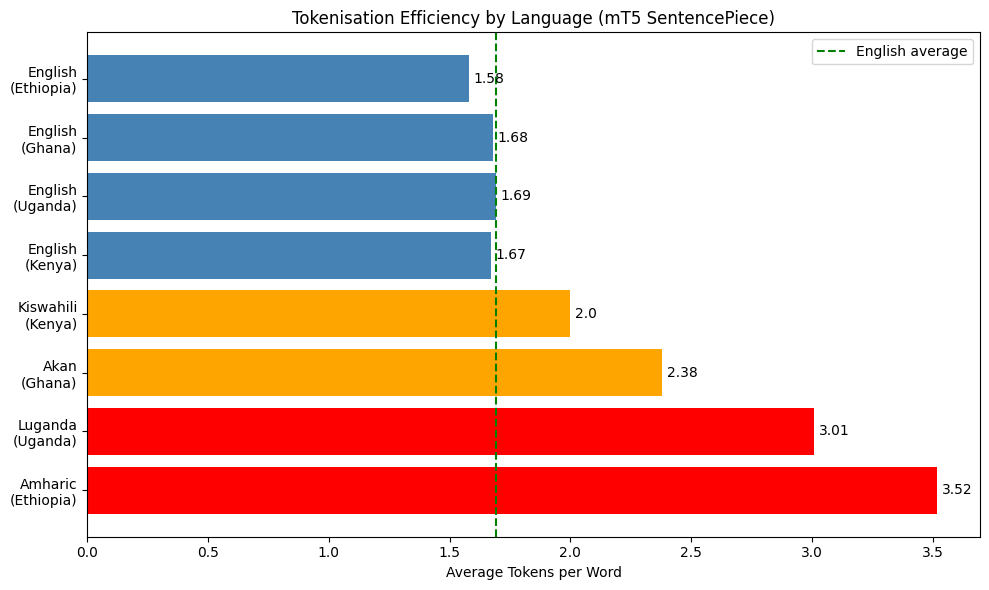

In [1]:
import matplotlib.pyplot as plt

languages = ['Amharic\n(Ethiopia)', 'Luganda\n(Uganda)', 'Akan\n(Ghana)', 
             'Kiswahili\n(Kenya)', 'English\n(Kenya)', 'English\n(Uganda)', 
             'English\n(Ghana)', 'English\n(Ethiopia)']
tokens_per_word = [3.52, 3.01, 2.38, 2.00, 1.67, 1.69, 1.68, 1.58]
colors = ['red' if t > 2.5 else 'orange' if t > 1.9 else 'steelblue' for t in tokens_per_word]

plt.figure(figsize=(10, 6))
bars = plt.barh(languages, tokens_per_word, color=colors)
plt.xlabel('Average Tokens per Word')
plt.title('Tokenisation Efficiency by Language (mT5 SentencePiece)')
plt.axvline(x=1.69, color='green', linestyle='--', label='English average')
for bar, val in zip(bars, tokens_per_word):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{val}', va='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('tokenisation.png', dpi=150, bbox_inches='tight')
plt.show()